###Entertainment and Media : Content recommentation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv", encoding='latin1')

df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added'] = df['date_added'].dt.year

##Heatmap of Content Added Over Years vs Type

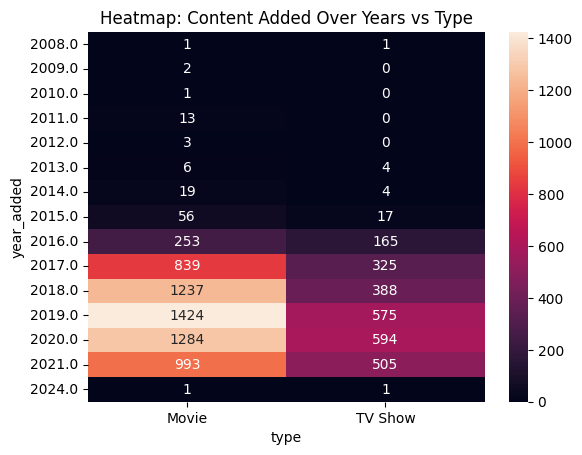

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df['year_added'] = df['date_added'].dt.year

pivot = pd.crosstab(df['year_added'], df['type'])

plt.figure()
sns.heatmap(pivot, annot=True, fmt="d")
plt.title("Heatmap: Content Added Over Years vs Type")
plt.show()

##Top Countries (Regional Recommendation)

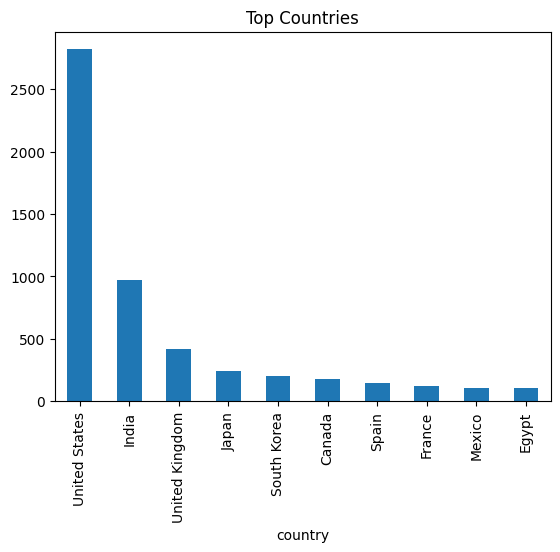

country
United States     2819
India              972
United Kingdom     419
Japan              245
South Korea        200
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64


In [3]:
country_counts = df['country'].value_counts().head(10)

plt.figure()
country_counts.plot(kind='bar')
plt.title("Top Countries")
plt.show()

print(country_counts)

##Duration vs Release Year (Insightful Scatter)

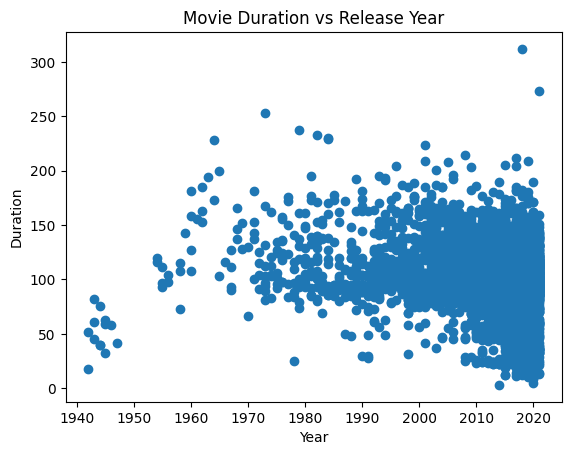

In [8]:
movies = df[df['type']=='Movie'].copy()
movies['duration_int'] = movies['duration'].str.extract(r'(\d+)').astype(float)

plt.figure()
plt.scatter(movies['release_year'], movies['duration_int'])
plt.title("Movie Duration vs Release Year")
plt.xlabel("Year")
plt.ylabel("Duration")
plt.show()

##Content Growth Curve (Smoothed Trend)

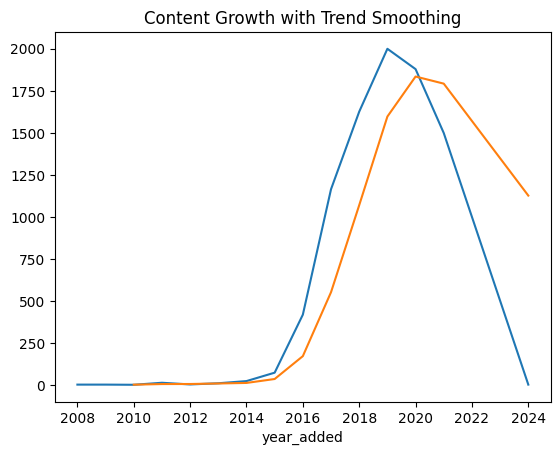

In [9]:
year_counts = df['year_added'].value_counts().sort_index()

plt.figure()
year_counts.plot()
year_counts.rolling(3).mean().plot()
plt.title("Content Growth with Trend Smoothing")
plt.show()

##Word Cloud of Titles (Looks Fancy, Zero Effort)

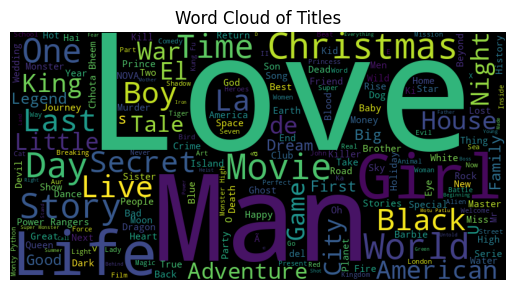

In [10]:
from wordcloud import WordCloud

text = " ".join(df['title'].dropna())

wc = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wc)
plt.axis('off')
plt.title("Word Cloud of Titles")
plt.show()

##Country vs Content Type (Stacked Bar)

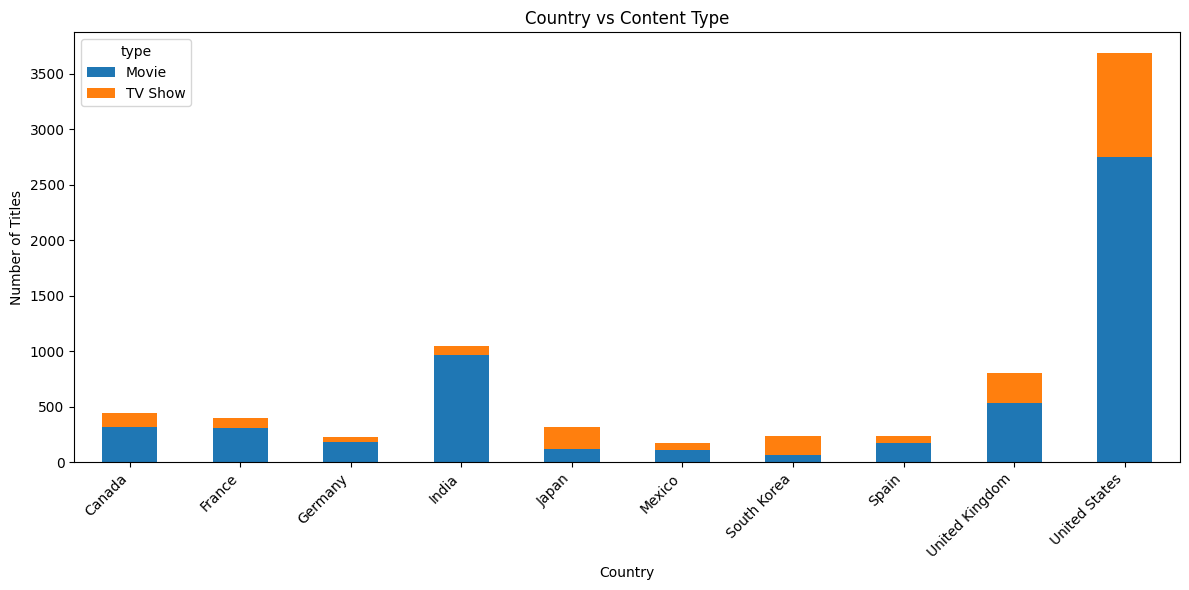

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
temp_df = df[['type', 'country']].copy()
temp_df['country'] = temp_df['country'].str.split(', ')
temp_df = temp_df.explode('country')
temp_df['country'] = temp_df['country'].str.strip()
temp_df.dropna(subset=['country'], inplace=True)
top_countries = temp_df['country'].value_counts().head(10).index
filtered_temp_df = temp_df[temp_df['country'].isin(top_countries)]
pivot = pd.crosstab(filtered_temp_df['country'], filtered_temp_df['type'])
plt.figure(figsize=(12, 6))
pivot.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title("Country vs Content Type")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()